# ESTUDIO ESTADISTICO

In [9]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu, kruskal, chi2_contingency, rankdata

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline


In [10]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================

base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df= pd.read_csv(os.path.join(base_path, "df_classified.csv"))

In [18]:
# ============================================================
# 2. PREPARACION DE DATOS PARA TESTS
# ============================================================

flux_cols = [c for c in ["flux_O2", "flux_smooth", "accumulated_flux_O2"] if c in df.columns]

sea_cols = [
    c for c in [
        "Oleaje", "Oleaje_SIMAR", "Mod_orbital", "STD_orbital",
        "mean_pres", "std_pres", "oleaje_clase", "cluster_kmeans", "oleaje_clase_nombre"
    ]
    if c in df.columns
]

other_cols = [c for c in ["mean_O2", "mean_vz", "mean_temp"] if c in df.columns]

vars_estudio = flux_cols + sea_cols + other_cols
df_estudio = df[["hour"] + vars_estudio].copy()

target_col = None
if "oleaje_clase" in df_estudio.columns:
    target_col = "oleaje_clase"
elif "cluster_kmeans" in df_estudio.columns:
    target_col = "cluster_kmeans"

# Solo convertir a numerico columnas cuantitativas (no etiquetas de clase)
non_numeric_cols = {"oleaje_clase_nombre"}
if target_col is not None:
    non_numeric_cols.add(target_col)

numeric_cols = [c for c in vars_estudio if c not in non_numeric_cols]
for col in numeric_cols:
    df_estudio[col] = pd.to_numeric(df_estudio[col], errors="coerce")

print("Variables de flujo:", flux_cols)
print("Variable de clase usada:", target_col)
print("Columnas tratadas como categoricas:", sorted(non_numeric_cols))
print(df_estudio[numeric_cols].isna().mean().sort_values(ascending=False).head(10))

Variables de flujo: ['flux_O2', 'flux_smooth', 'accumulated_flux_O2']
Variable de clase usada: oleaje_clase
Columnas tratadas como categoricas: ['oleaje_clase', 'oleaje_clase_nombre']
Oleaje                 0.166667
flux_O2                0.000000
flux_smooth            0.000000
accumulated_flux_O2    0.000000
Oleaje_SIMAR           0.000000
Mod_orbital            0.000000
STD_orbital            0.000000
mean_pres              0.000000
std_pres               0.000000
cluster_kmeans         0.000000
dtype: float64


## 6.1 Tests estadisticos

In [12]:
# ============================================================
# 6.1 MANN-WHITNEY U / KRUSKAL-WALLIS: flux_O2 por estado de oleaje
# ============================================================

ALPHA = 0.05
n_clases = 0
p = None
clases = []
grupos = pd.DataFrame()

if target_col is not None and "flux_O2" in df_estudio.columns:
    grupos = df_estudio[[target_col, "flux_O2"]].dropna()
    clases = sorted(grupos[target_col].unique())
    n_clases = len(clases)

    print(f"Estados de oleaje encontrados ({n_clases}): {clases}\n")

    if n_clases < 2:
        print("Se necesitan al menos 2 grupos para ejecutar el test.")
    else:
        muestras = [grupos.loc[grupos[target_col] == c, "flux_O2"].values for c in clases]

        if n_clases == 2:
            stat, p = mannwhitneyu(*muestras, alternative="two-sided")
            test_usado = "Mann-Whitney U"
        else:
            stat, p = kruskal(*muestras)
            test_usado = "Kruskal-Wallis"

        interpretacion = (
            "Existen diferencias significativas entre estados de oleaje (p < 0.05)."
            if p < ALPHA else
            "No hay evidencia suficiente de diferencias significativas (p >= 0.05)."
        )

        print(f"Test: {test_usado}")
        print(f"  Estadistico = {stat:.4f}")
        print(f"  p-value     = {p:.4f}")
        print(f"  -> {interpretacion}")
else:
    print("No se puede ejecutar: falta 'flux_O2' o la variable de clase.")

Estados de oleaje encontrados (2): [np.int64(0), np.int64(1)]

Test: Mann-Whitney U
  Estadistico = 62255.0000
  p-value     = 0.0009
  -> Existen diferencias significativas entre estados de oleaje (p < 0.05).


### 6.2 Post-hoc por pares
Se ejecuta solo si hay mas de dos clases y el test global resulta significativo.

In [13]:
# ============================================================
# 6.2 POST-HOC por pares (solo si Kruskal-Wallis fue significativo)
# ============================================================
from itertools import combinations

if n_clases > 2 and p is not None and p < ALPHA:
    pares = list(combinations(clases, 2))
    n_pares = len(pares)

    resultados_posthoc = []

    for c1, c2 in pares:
        m1 = grupos.loc[grupos[target_col] == c1, "flux_O2"].values
        m2 = grupos.loc[grupos[target_col] == c2, "flux_O2"].values
        stat_par, p_par = mannwhitneyu(m1, m2, alternative="two-sided")
        resultados_posthoc.append({
            "grupo_1": c1,
            "grupo_2": c2,
            "U_stat": round(stat_par, 4),
            "p_valor": round(p_par, 6),
        })

    df_posthoc = pd.DataFrame(resultados_posthoc)

    # Correccion Bonferroni
    df_posthoc["p_bonferroni"] = (df_posthoc["p_valor"] * n_pares).clip(upper=1.0).round(6)

    # Correccion FDR (Benjamini-Hochberg)
    ranks = rankdata(df_posthoc["p_valor"].values)
    df_posthoc["p_fdr"] = (df_posthoc["p_valor"] * n_pares / ranks).clip(upper=1.0).round(6)

    df_posthoc["sig_bonferroni"] = df_posthoc["p_bonferroni"] < ALPHA
    df_posthoc["sig_fdr"] = df_posthoc["p_fdr"] < ALPHA

    print(f"Post-hoc Mann-Whitney U con correccion multiple ({n_pares} comparaciones):\n")
    display(df_posthoc)
elif n_clases <= 2:
    print("Solo hay 2 grupos (o menos) -> no se requiere post-hoc.")
elif p is not None and p >= ALPHA:
    print("Kruskal-Wallis no fue significativo -> no se realiza post-hoc.")
else:
    print("No se puede ejecutar el post-hoc.")

Solo hay 2 grupos (o menos) -> no se requiere post-hoc.


### 6.3 Asociacion entre spikes y estado de oleaje
Contraste de independencia con chi-cuadrado sobre tabla de contingencia.

In [14]:
# ============================================================
# 6.3 CHI-CUADRADO: spikes de O2 vs estado de oleaje
# ============================================================

spike_col = None
for candidate in ["flag_outlier_window", "outlier_O2", "flag_outlier_global"]:
    if candidate in df.columns:
        spike_col = candidate
        break

if spike_col is not None and target_col is not None:
    df_chi = df[[target_col, spike_col]].dropna().copy()
    df_chi[spike_col] = df_chi[spike_col].astype(bool)

    tabla_contingencia = pd.crosstab(
        df_chi[target_col],
        df_chi[spike_col],
        rownames=["estado_oleaje"],
        colnames=["spike_O2"]
    )

    chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)

    interp_chi = (
        "La presencia de spikes depende significativamente del estado de oleaje (p < 0.05)."
        if p_chi < ALPHA else
        "No hay evidencia de dependencia entre spikes y estado de oleaje (p >= 0.05)."
    )

    print(f"Tabla de contingencia ({target_col} x {spike_col}):")
    display(tabla_contingencia)
    print(f"\nChi-cuadrado: {chi2:.4f}")
    print(f"p-value:      {p_chi:.4f}")
    print(f"Grados de libertad: {dof}")
    print(f"-> {interp_chi}")
else:
    print("No se encontro columna de spikes o variable de clase.")

Tabla de contingencia (oleaje_clase x flag_outlier_window):


spike_O2,False,True
estado_oleaje,,
0,179,127
1,159,195



Chi-cuadrado: 11.5794
p-value:      0.0007
Grados de libertad: 1
-> La presencia de spikes depende significativamente del estado de oleaje (p < 0.05).


### 6.4 Correlaciones de Spearman
Analisis no parametrico entre flux_O2 y variables hidrodinamicas.

In [15]:
# ============================================================
# 6.4 CORRELACIONES DE SPEARMAN: flux_O2 vs variables hidrodinamicas
# ============================================================

hidro_cols = {
    "altura_ola": ["Oleaje_SIMAR", "Oleaje"],
    "velocidad_orbital": ["Mod_orbital", "STD_orbital"],
    "presion": ["mean_pres", "std_pres"],
}

if "flux_O2" in df_estudio.columns:
    resultados_spear = []

    for etiqueta, candidatos in hidro_cols.items():
        col_real = next((c for c in candidatos if c in df_estudio.columns), None)
        if col_real is None:
            print(f"No se encontro columna para '{etiqueta}' ({candidatos})")
            continue

        aux = df_estudio[["flux_O2", col_real]].dropna()
        if len(aux) < 5:
            print(f"Muy pocos datos para '{etiqueta}'")
            continue

        rho, p_sp = spearmanr(aux["flux_O2"], aux[col_real])

        if p_sp < ALPHA:
            interp = f"Correlacion significativa (rho={rho:.3f}, p={p_sp:.4f})."
        else:
            interp = f"No significativa (rho={rho:.3f}, p={p_sp:.4f})."

        resultados_spear.append({
            "variable": etiqueta,
            "columna_usada": col_real,
            "spearman_rho": round(rho, 4),
            "p_value": round(p_sp, 6),
            "n": len(aux),
            "interpretacion": interp,
        })

    df_spearman = pd.DataFrame(resultados_spear)
    display(df_spearman)
else:
    print("'flux_O2' no esta en df_estudio.")

,variable,columna_usada,spearman_rho,p_value,n,interpretacion
0,altura_ola,Oleaje_SIMAR,-0.1694,0.000012,660,"Correlacion significativa (rho=-0.169, p=0.0000)."
1,velocidad_orbital,Mod_orbital,-0.1774,0.000005,660,"Correlacion significativa (rho=-0.177, p=0.0000)."
2,presion,mean_pres,0.0305,0.433604,660,"No significativa (rho=0.031, p=0.4336)."


### 6.5 Graficos de soporte
Visualizaciones para interpretar los resultados de los tests.

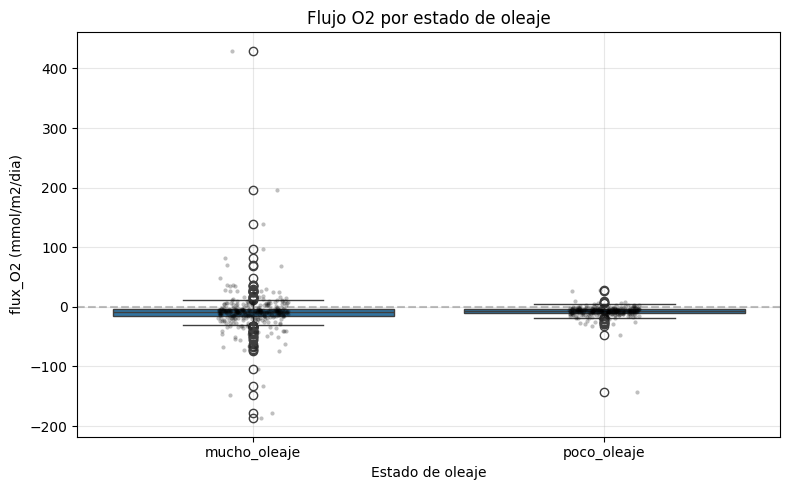

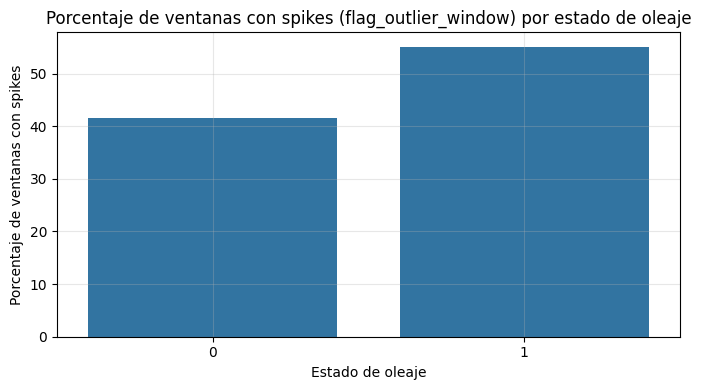

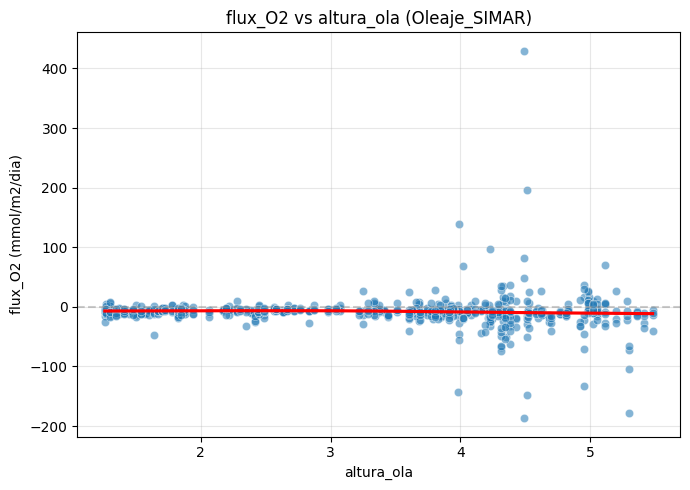

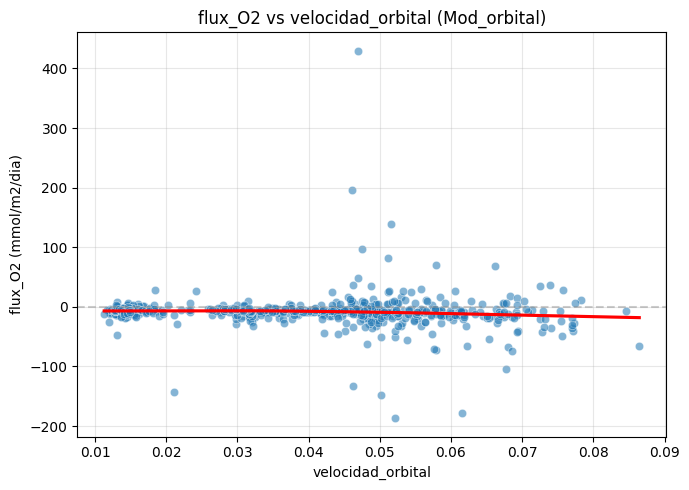

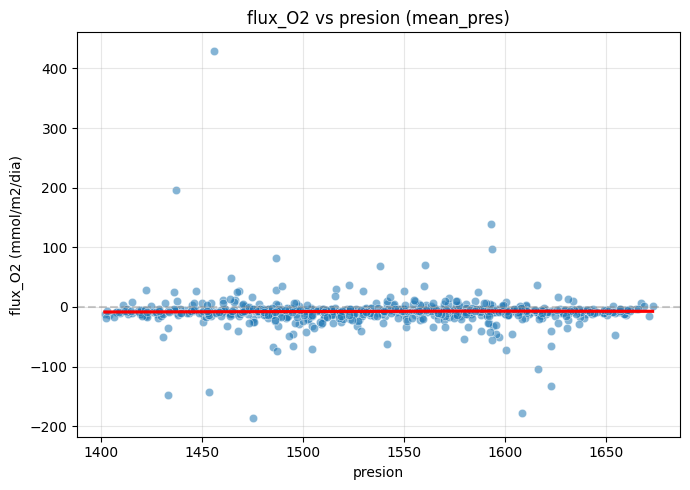

In [19]:
# ============================================================
# 6.5 GRAFICOS ESTADISTICOS
# ============================================================

nombre_clase_col = "oleaje_clase_nombre" if "oleaje_clase_nombre" in df_estudio.columns else target_col

# A) Boxplot flux_O2 por estado de oleaje
if target_col is not None and "flux_O2" in df_estudio.columns:
    x_col = nombre_clase_col if nombre_clase_col in df_estudio.columns else target_col
    df_box = df_estudio[[x_col, "flux_O2"]].dropna().copy()

    if df_box.empty:
        print("No hay datos suficientes para el boxplot (x o flux_O2 vacios).")
    else:
        # Fuerza categorias estables para evitar errores de posiciones en seaborn/matplotlib
        df_box[x_col] = df_box[x_col].astype(str)
        order = sorted(df_box[x_col].unique())

        plt.figure(figsize=(8, 5))
        sns.boxplot(
            data=df_box,
            x=x_col,
            y="flux_O2",
            order=order,
        )
        sns.stripplot(
            data=df_box,
            x=x_col,
            y="flux_O2",
            order=order,
            color="black",
            alpha=0.25,
            size=3,
        )
        plt.axhline(0, linestyle="--", color="gray", alpha=0.5)
        plt.title("Flujo O2 por estado de oleaje")
        plt.xlabel("Estado de oleaje")
        plt.ylabel("flux_O2 (mmol/m2/dia)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# B) Barras: porcentaje de ventanas con spikes por estado de oleaje
if spike_col is not None and target_col is not None:
    df_spike_pct = (
        df[[target_col, spike_col]].dropna()
        .assign(**{spike_col: lambda x: x[spike_col].astype(bool)})
        .groupby(target_col)[spike_col]
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={spike_col: "pct_spikes"})
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_spike_pct, x=target_col, y="pct_spikes")
    plt.title(f"Porcentaje de ventanas con spikes ({spike_col}) por estado de oleaje")
    plt.xlabel("Estado de oleaje")
    plt.ylabel("Porcentaje de ventanas con spikes")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# C) Scatterplots flux_O2 vs variables hidrodinamicas
if "flux_O2" in df_estudio.columns:
    for etiqueta, candidatos in hidro_cols.items():
        col_real = next((c for c in candidatos if c in df_estudio.columns), None)
        if col_real is None:
            continue

        df_sc = df_estudio[[col_real, "flux_O2"]].dropna()
        if df_sc.empty:
            continue

        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=df_sc, x=col_real, y="flux_O2", alpha=0.55)
        sns.regplot(
            data=df_sc,
            x=col_real,
            y="flux_O2",
            scatter=False,
            lowess=True,
            color="red",
        )
        plt.title(f"flux_O2 vs {etiqueta} ({col_real})")
        plt.xlabel(etiqueta)
        plt.ylabel("flux_O2 (mmol/m2/dia)")
        plt.axhline(0, linestyle="--", color="gray", alpha=0.4)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()